# Prophet – Daily Waste Forecast per Canteen Section

Trains a separate Prophet model per canteen section using daily aggregated waste data.
Features: `Foot_Traffic`, `is_holiday`, `is_special_day` as regressors.
Split: chronological train / validation / test (no leakage).
Hyperparameter tuning via cross-validation on the training set only.
Goal: given a date, predict the upcoming 7-day waste per section.

In [32]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## Configuration

In [33]:
DATA_PATH  = 'data/food_waste_features.csv'
MODEL_DIR  = 'deployment_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Chronological split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Hyperparameter grid searched on validation set via CV
PARAM_GRID = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.3],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode':        ['additive', 'multiplicative'],
}

FORECAST_HORIZON = 7   # days to forecast
print('Config ready.')

Config ready.


## Load & Aggregate Data

The raw data has 30-min meal-slot timestamps (~3 meals × 2 slots/meal = 6 records/day/section).
Sub-daily resampling yields >97% empty bins, so we aggregate to **daily** totals per section.
Regressors (`Foot_Traffic`, `is_holiday`, `is_special_day`) are summed/max-aggregated per day.

In [34]:
df = pd.read_csv(DATA_PATH, parse_dates=['time_bin'])
print('Raw shape:', df.shape)
df.head()

Raw shape: (11851, 7)


,Canteen_Section,time_bin,Waste_Weight_kg,Cost_Loss,Foot_Traffic,is_holiday,is_special_day
0,A,2015-01-01 17:00:00,3.82,11.46,100.0,1,1
1,A,2015-01-03 11:30:00,6.85,10.27,84.0,0,1
2,A,2015-01-04 12:00:00,2.08,4.15,84.0,0,1
3,A,2015-01-05 11:30:00,3.61,7.22,120.0,0,0
4,A,2015-01-07 06:00:00,0.69,5.48,80.0,0,0


In [35]:
df['date'] = df['time_bin'].dt.normalize()  # floor to day

daily = (
    df.groupby(['Canteen_Section', 'date'])
      .agg(
          y            = ('Waste_Weight_kg', 'sum'),
          foot_traffic = ('Foot_Traffic',    'sum'),
          is_holiday   = ('is_holiday',      'max'),
          is_special_day = ('is_special_day','max'),
      )
      .reset_index()
      .rename(columns={'date': 'ds', 'Canteen_Section': 'section'})
)

sections = sorted(daily['section'].unique())
print('Daily shape:', daily.shape)
print('Sections:', sections)
daily.head()

Daily shape: (7428, 6)
Sections: ['A', 'B', 'C', 'D']


,section,ds,y,foot_traffic,is_holiday,is_special_day
0,A,2015-01-01,3.82,100.0,1,1
1,A,2015-01-03,6.85,84.0,0,1
2,A,2015-01-04,2.08,84.0,0,1
3,A,2015-01-05,3.61,120.0,0,0
4,A,2015-01-07,0.69,80.0,0,0


## Chronological Train / Validation / Test Split

Splits are based on the **global** date range so all sections share the same cutoffs.
This prevents any future data leaking into training.

In [36]:
all_dates = sorted(daily['ds'].unique())
n = len(all_dates)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

train_end = all_dates[n_train - 1]
val_end   = all_dates[n_train + n_val - 1]
test_start = all_dates[n_train + n_val]

print(f'Total unique days : {n}')
print(f'Train  : up to      {train_end.date()}  ({n_train} days)')
print(f'Val    : {all_dates[n_train].date()} – {val_end.date()}  ({n_val} days)')
print(f'Test   : {test_start.date()} – {all_dates[-1].date()}  ({n - n_train - n_val} days)')

Total unique days : 3480
Train  : up to      2022-02-24  (2436 days)
Val    : 2022-02-25 – 2023-08-30  (522 days)
Test   : 2023-08-31 – 2025-08-10  (522 days)


## Helper Functions

In [37]:
def split_section(df_sec):
    """Return train/val/test DataFrames for one section (no leakage)."""
    train = df_sec[df_sec['ds'] <= train_end].copy()
    val   = df_sec[(df_sec['ds'] > train_end) & (df_sec['ds'] <= val_end)].copy()
    test  = df_sec[df_sec['ds'] > val_end].copy()
    return train, val, test


def metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan
    r2   = r2_score(y_true, y_pred)
    return dict(RMSE=rmse, MAE=mae, MAPE=mape, R2=r2)


def build_prophet(params):
    m = Prophet(
        yearly_seasonality  = True,
        weekly_seasonality  = True,
        daily_seasonality   = False,
        changepoint_prior_scale  = params['changepoint_prior_scale'],
        seasonality_prior_scale  = params['seasonality_prior_scale'],
        seasonality_mode         = params['seasonality_mode'],
    )
    m.add_regressor('foot_traffic')
    m.add_regressor('is_holiday')
    m.add_regressor('is_special_day')
    return m

print('Helpers defined.')

Helpers defined.


## Hyperparameter Tuning via Cross-Validation

We search the parameter grid using Prophet's built-in `cross_validation` **on the training set only**.
CV uses an expanding window (initial = 70% of train, horizon = 30 days, step = 15 days).
Best params are selected per section by minimising RMSE on the CV folds.

In [38]:
param_combinations = [
    dict(zip(PARAM_GRID.keys(), v))
    for v in itertools.product(*PARAM_GRID.values())
]
print(f'{len(param_combinations)} parameter combinations to evaluate per section.')

24 parameter combinations to evaluate per section.


In [39]:
best_params_per_section = {}

for sec in sections:
    print(f'\n{"="*55}\nTuning section {sec}\n{"="*55}')
    df_sec = daily[daily['section'] == sec].sort_values('ds').reset_index(drop=True)
    train_df, val_df, test_df = split_section(df_sec)

    if len(train_df) < 60:
        print(f'  Not enough training data ({len(train_df)} rows), using defaults.')
        best_params_per_section[sec] = param_combinations[0]
        continue

    # CV horizon / initial based on training length
    cv_horizon = '30 days'
    cv_initial = f'{max(60, int(len(train_df) * 0.7))} days'
    cv_period  = '15 days'

    best_rmse, best_p = np.inf, None
    for p in param_combinations:
        try:
            m = build_prophet(p)
            m.fit(train_df[['ds','y','foot_traffic','is_holiday','is_special_day']])
            cv_df  = cross_validation(m, initial=cv_initial, period=cv_period,
                                      horizon=cv_horizon, disable_tqdm=True)
            perf   = performance_metrics(cv_df, rolling_window=1)
            rmse   = perf['rmse'].mean()
            if rmse < best_rmse:
                best_rmse, best_p = rmse, p
        except Exception as e:
            pass

    best_params_per_section[sec] = best_p or param_combinations[0]
    print(f'  Best CV RMSE: {best_rmse:.4f}')
    print(f'  Best params : {best_p}')

print('\nTuning complete.')

15:29:58 - cmdstanpy - INFO - Chain [1] start processing



Tuning section A


15:29:58 - cmdstanpy - INFO - Chain [1] done processing
15:29:58 - cmdstanpy - INFO - Chain [1] start processing
15:29:58 - cmdstanpy - INFO - Chain [1] done processing
15:29:58 - cmdstanpy - INFO - Chain [1] start processing
15:29:58 - cmdstanpy - INFO - Chain [1] done processing
15:29:58 - cmdstanpy - INFO - Chain [1] start processing
15:29:58 - cmdstanpy - INFO - Chain [1] done processing
15:29:58 - cmdstanpy - INFO - Chain [1] start processing
15:29:59 - cmdstanpy - INFO - Chain [1] done processing
15:29:59 - cmdstanpy - INFO - Chain [1] start processing
15:29:59 - cmdstanpy - INFO - Chain [1] done processing
15:29:59 - cmdstanpy - INFO - Chain [1] start processing
15:29:59 - cmdstanpy - INFO - Chain [1] done processing
15:29:59 - cmdstanpy - INFO - Chain [1] start processing
15:29:59 - cmdstanpy - INFO - Chain [1] done processing
15:29:59 - cmdstanpy - INFO - Chain [1] start processing
15:29:59 - cmdstanpy - INFO - Chain [1] done processing
15:29:59 - cmdstanpy - INFO - Chain [1] 

  Best CV RMSE: 3.5351
  Best params : {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}

Tuning section B


15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] start processing
15:33:16 - cmdstanpy - INFO - Chain [1] done processing
15:33:16 - cmdstanpy - INFO - Chain [1] 

  Best CV RMSE: 3.9856
  Best params : {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}

Tuning section C


15:36:35 - cmdstanpy - INFO - Chain [1] done processing
15:36:35 - cmdstanpy - INFO - Chain [1] start processing
15:36:35 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] start processing
15:36:36 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] start processing
15:36:36 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] start processing
15:36:36 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] start processing
15:36:36 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] start processing
15:36:36 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] start processing
15:36:36 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] start processing
15:36:36 - cmdstanpy - INFO - Chain [1] done processing
15:36:36 - cmdstanpy - INFO - Chain [1] 

  Best CV RMSE: 3.1810
  Best params : {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}

Tuning section D


15:39:44 - cmdstanpy - INFO - Chain [1] start processing
15:39:44 - cmdstanpy - INFO - Chain [1] done processing
15:39:44 - cmdstanpy - INFO - Chain [1] start processing
15:39:44 - cmdstanpy - INFO - Chain [1] done processing
15:39:44 - cmdstanpy - INFO - Chain [1] start processing
15:39:44 - cmdstanpy - INFO - Chain [1] done processing
15:39:45 - cmdstanpy - INFO - Chain [1] start processing
15:39:45 - cmdstanpy - INFO - Chain [1] done processing
15:39:45 - cmdstanpy - INFO - Chain [1] start processing
15:39:45 - cmdstanpy - INFO - Chain [1] done processing
15:39:45 - cmdstanpy - INFO - Chain [1] start processing
15:39:45 - cmdstanpy - INFO - Chain [1] done processing
15:39:45 - cmdstanpy - INFO - Chain [1] start processing
15:39:45 - cmdstanpy - INFO - Chain [1] done processing
15:39:45 - cmdstanpy - INFO - Chain [1] start processing
15:39:45 - cmdstanpy - INFO - Chain [1] done processing
15:39:45 - cmdstanpy - INFO - Chain [1] start processing
15:39:45 - cmdstanpy - INFO - Chain [1]

  Best CV RMSE: 4.1043
  Best params : {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}

Tuning complete.


## Train Final Models & Evaluate on Test Set

Each section's model is retrained on **train + validation** data using the best hyperparameters,
then evaluated on the held-out test set.

In [40]:
all_metrics = []
trained_models = {}

for sec in sections:
    print(f'\n{"="*55}\nFinal training – section {sec}\n{"="*55}')
    df_sec = daily[daily['section'] == sec].sort_values('ds').reset_index(drop=True)
    train_df, val_df, test_df = split_section(df_sec)

    # Combine train + val for final fit
    trainval_df = pd.concat([train_df, val_df]).sort_values('ds').reset_index(drop=True)
    feat_cols   = ['ds','y','foot_traffic','is_holiday','is_special_day']

    p = best_params_per_section[sec]
    m = build_prophet(p)
    m.fit(trainval_df[feat_cols])

    # Predict on test set
    future = test_df[['ds','foot_traffic','is_holiday','is_special_day']].copy()
    forecast = m.predict(future)
    test_df = test_df.merge(forecast[['ds','yhat','yhat_lower','yhat_upper']], on='ds', how='left')
    test_df['yhat'] = test_df['yhat'].clip(lower=0)

    m_dict = metrics(test_df['y'], test_df['yhat'])
    print(f'  RMSE={m_dict["RMSE"]:.3f}  MAE={m_dict["MAE"]:.3f}  '
          f'MAPE={m_dict["MAPE"]:.1f}%  R2={m_dict["R2"]:.3f}')

    all_metrics.append({'Section': sec, **m_dict})
    trained_models[sec] = {'model': m, 'test_df': test_df,
                            'trainval_df': trainval_df, 'params': p}

print('\nAll sections trained.')

15:42:54 - cmdstanpy - INFO - Chain [1] start processing
15:42:54 - cmdstanpy - INFO - Chain [1] done processing
15:42:55 - cmdstanpy - INFO - Chain [1] start processing



Final training – section A
  RMSE=4.646  MAE=3.147  MAPE=91.7%  R2=0.780

Final training – section B


15:42:55 - cmdstanpy - INFO - Chain [1] done processing
15:42:55 - cmdstanpy - INFO - Chain [1] start processing
15:42:55 - cmdstanpy - INFO - Chain [1] done processing
15:42:55 - cmdstanpy - INFO - Chain [1] start processing
15:42:55 - cmdstanpy - INFO - Chain [1] done processing


  RMSE=5.310  MAE=3.408  MAPE=95.1%  R2=0.758

Final training – section C
  RMSE=5.026  MAE=3.190  MAPE=120.4%  R2=0.777

Final training – section D
  RMSE=4.662  MAE=3.315  MAPE=99.5%  R2=0.794

All sections trained.


## Test-Set Performance Summary

In [41]:
summary_df = pd.DataFrame(all_metrics).set_index('Section')
summary_df = summary_df.round(4)
print(summary_df.to_string())
summary_df.to_csv(f'{MODEL_DIR}/test_metrics_Prophet.csv')
print('\nSaved to deployment_models/test_metrics_Prophet.csv')

           RMSE     MAE      MAPE      R2
Section                                  
A        4.6464  3.1466   91.6934  0.7804
B        5.3102  3.4079   95.1139  0.7581
C        5.0257  3.1902  120.3786  0.7771
D        4.6624  3.3147   99.5309  0.7942

Saved to deployment_models/test_metrics_Prophet.csv


## Predictions vs Actuals on Test Set

Each subplot shows the actual daily waste (blue) and the Prophet forecast (orange) with
the 80% uncertainty interval shaded.

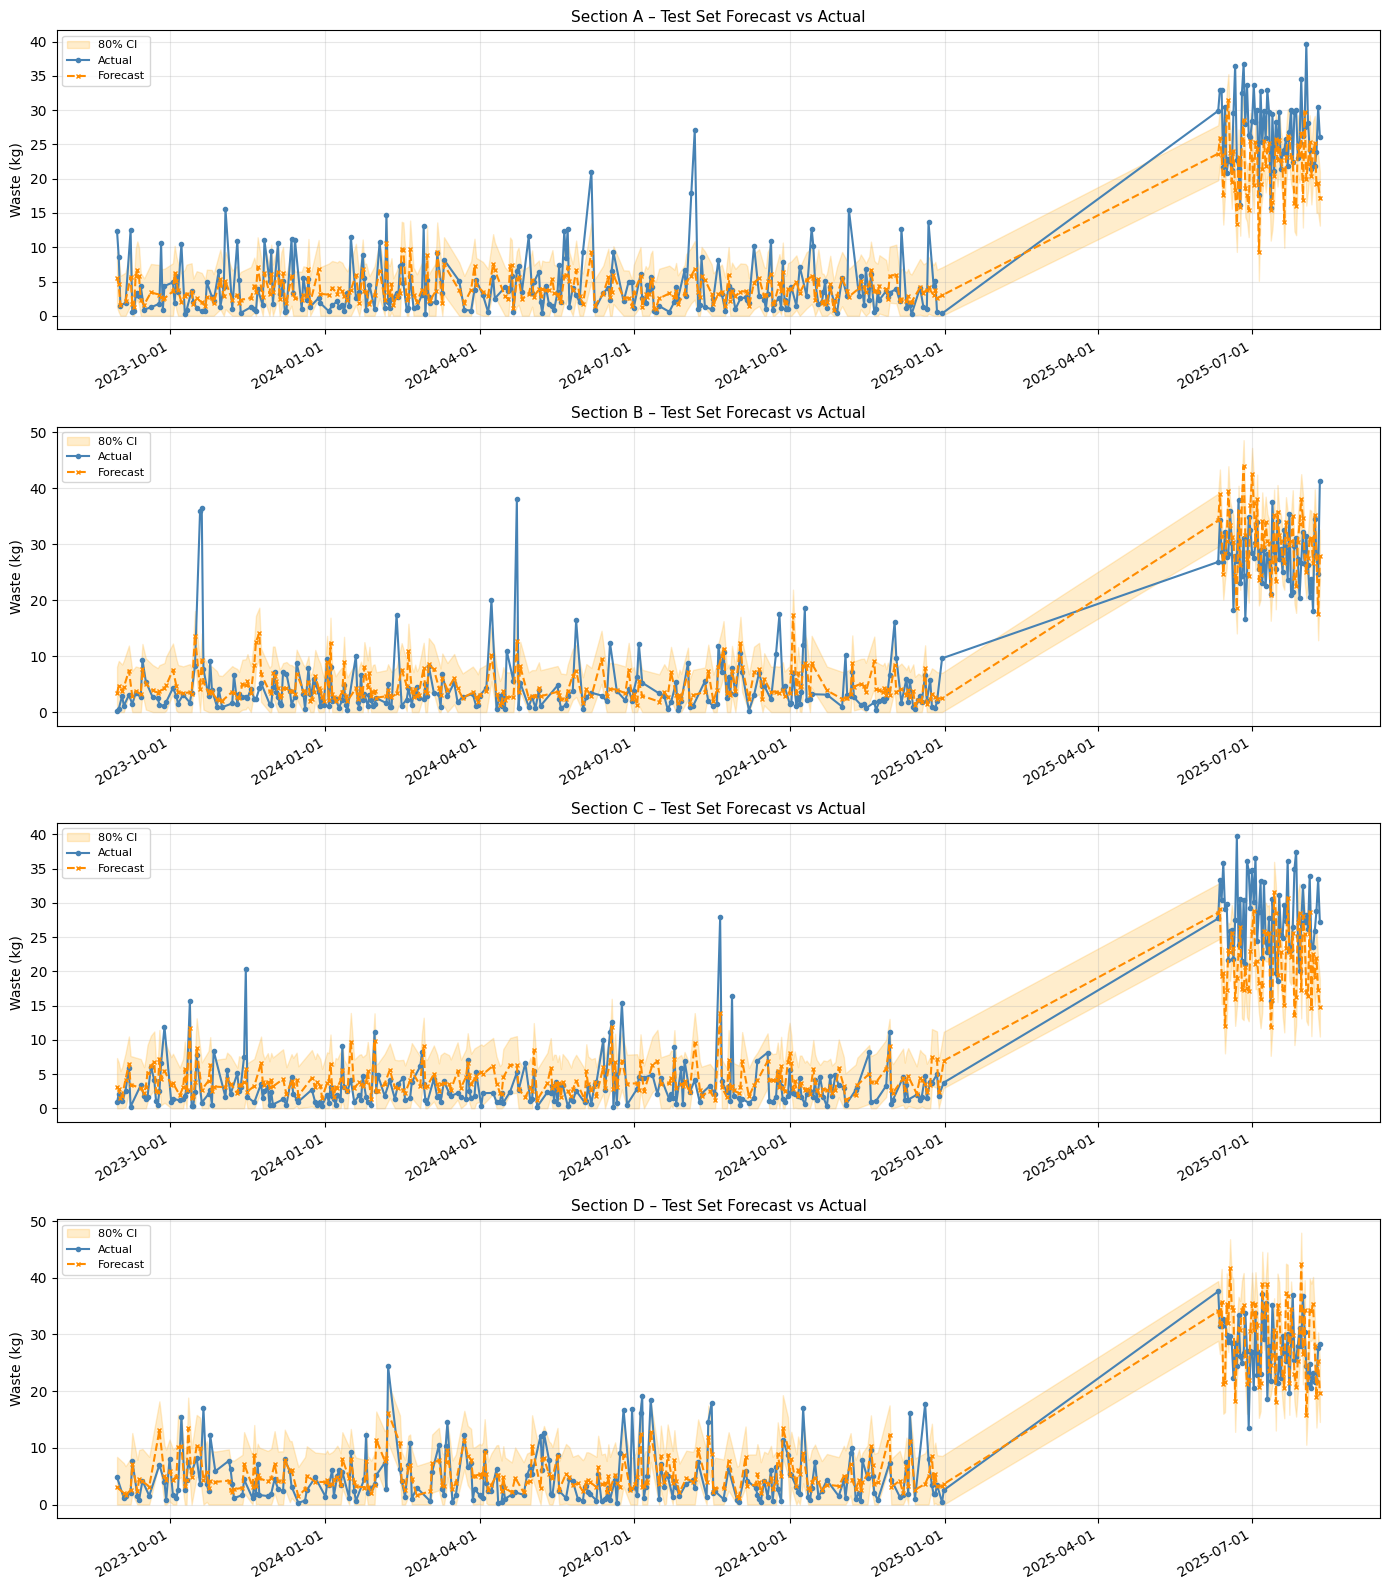

Plot saved.


In [42]:
fig, axes = plt.subplots(len(sections), 1, figsize=(14, 4 * len(sections)), sharex=False)
if len(sections) == 1:
    axes = [axes]

for ax, sec in zip(axes, sections):
    tdf = trained_models[sec]['test_df'].sort_values('ds')
    ax.fill_between(tdf['ds'], tdf['yhat_lower'].clip(0), tdf['yhat_upper'],
                    alpha=0.2, color='orange', label='80% CI')
    ax.plot(tdf['ds'], tdf['y'],    color='steelblue', lw=1.5, marker='o',
            markersize=3, label='Actual')
    ax.plot(tdf['ds'], tdf['yhat'], color='darkorange', lw=1.5, linestyle='--',
            marker='x', markersize=3, label='Forecast')
    ax.set_title(f'Section {sec} – Test Set Forecast vs Actual', fontsize=11)
    ax.set_ylabel('Waste (kg)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/Prophet_test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Weekly Forecast Function

Given a start date, predict the next 7 days of waste for every canteen section.
Regressor values for future dates are estimated from the training-set median.

In [43]:
def forecast_week(start_date: str, section: str = None):
    """
    Predict daily waste for the 7 days starting from `start_date`.

    Parameters
    ----------
    start_date : str  e.g. '2025-09-01'
    section    : str or None  – if None, forecasts all sections

    Returns
    -------
    pd.DataFrame with columns [ds, section, yhat, yhat_lower, yhat_upper]
    """
    start = pd.Timestamp(start_date)
    future_dates = pd.date_range(start, periods=7, freq='D')
    secs = [section] if section else sections
    results = []

    for sec in secs:
        info = trained_models[sec]
        tv   = info['trainval_df']
        # Use median regressor values from training data as future estimates
        med_ft  = tv['foot_traffic'].median()
        med_hol = 0   # assume no holiday by default
        med_sp  = 0

        future_df = pd.DataFrame({
            'ds':            future_dates,
            'foot_traffic':  med_ft,
            'is_holiday':    med_hol,
            'is_special_day': med_sp,
        })
        fc = info['model'].predict(future_df)
        fc['yhat']       = fc['yhat'].clip(lower=0)
        fc['yhat_lower'] = fc['yhat_lower'].clip(lower=0)
        fc['section']    = sec
        results.append(fc[['ds','section','yhat','yhat_lower','yhat_upper']])

    return pd.concat(results).reset_index(drop=True)


# Demo: forecast the week starting 2025-09-01
demo = forecast_week('2025-09-01')
print(demo.to_string(index=False))

        ds section     yhat  yhat_lower  yhat_upper
2025-09-01       A 3.135153    0.000000    6.922489
2025-09-02       A 2.740790    0.000000    6.620261
2025-09-03       A 3.026417    0.000000    6.841442
2025-09-04       A 3.005080    0.000000    7.109832
2025-09-05       A 2.782737    0.000000    7.301909
2025-09-06       A 2.824489    0.000000    6.865217
2025-09-07       A 2.689280    0.000000    6.901228
2025-09-01       B 3.926284    0.000000    8.277290
2025-09-02       B 4.063726    0.000000    8.540526
2025-09-03       B 3.682908    0.000000    8.395887
2025-09-04       B 4.320222    0.000000    8.985212
2025-09-05       B 3.986322    0.000000    8.448268
2025-09-06       B 4.654581    0.339344    9.203050
2025-09-07       B 4.932789    0.222071    9.432780
2025-09-01       C 3.465646    0.000000    7.835056
2025-09-02       C 3.752649    0.000000    7.953997
2025-09-03       C 3.472802    0.000000    7.441802
2025-09-04       C 3.407786    0.000000    7.377359
2025-09-05  

### Visualise the 7-Day Forecast

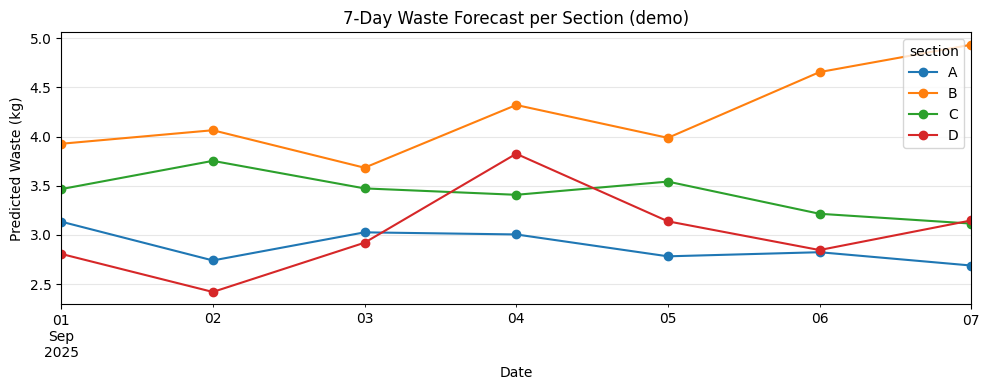

In [44]:
demo_pivot = demo.pivot(index='ds', columns='section', values='yhat')
demo_pivot.plot(figsize=(10, 4), marker='o', title='7-Day Waste Forecast per Section (demo)')
plt.ylabel('Predicted Waste (kg)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Models

In [45]:
for sec in sections:
    info = trained_models[sec]
    artifact = {
        'section':  sec,
        'model':    info['model'],
        'params':   info['params'],
        'train_end': str(train_end.date()),
        'val_end':   str(val_end.date()),
        'test_start': str(test_start.date()),
    }
    path = f'{MODEL_DIR}/section_{sec}_Prophet.joblib'
    joblib.dump(artifact, path)
    print(f'Saved {path}')

Saved deployment_models/section_A_Prophet.joblib
Saved deployment_models/section_B_Prophet.joblib
Saved deployment_models/section_C_Prophet.joblib
Saved deployment_models/section_D_Prophet.joblib
